## Imports and Load dataframe

Guide reference can be found [here](https://www.quarkml.com/2022/05/iris-dataset-classification-with-python.html)

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()

## DataFrame Analysis

In [29]:
print(iris.keys())

pd.set_option('display.width', 500)
df = pd.DataFrame(
    data = np.c_[iris['data'], iris['target']],
    columns = iris['feature_names'] + ['target']
)

species = []

for i in range(len(df['target'])):
    if df['target'][i] == 0:
        species.append("setosa")
    elif df['target'][i] == 1:
        species.append('versicolor')
    else:
        species.append('virginica')

df['species'] = species

print(df.head(10))
df.describe()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target species
0                5.1               3.5                1.4               0.2     0.0  setosa
1                4.9               3.0                1.4               0.2     0.0  setosa
2                4.7               3.2                1.3               0.2     0.0  setosa
3                4.6               3.1                1.5               0.2     0.0  setosa
4                5.0               3.6                1.4               0.2     0.0  setosa
5                5.4               3.9                1.7               0.4     0.0  setosa
6                4.6               3.4                1.4               0.3     0.0  setosa
7                5.0               3.4                1.5               0.2     0.0  setosa
8                4.4               2.9                1.4       

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Plotting the Dataset

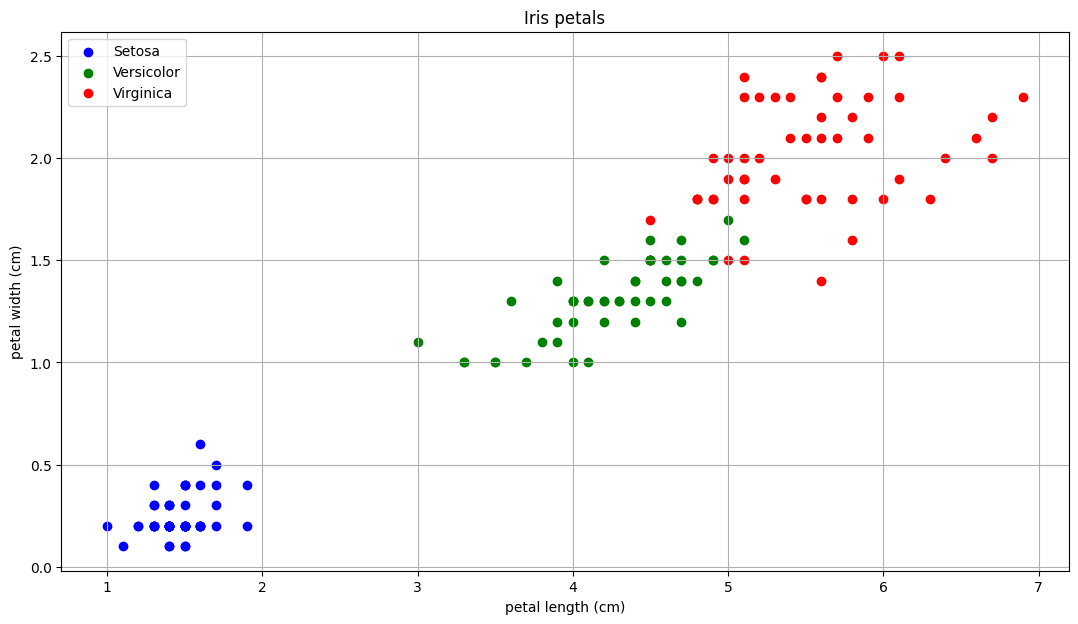

In [20]:
import matplotlib.pyplot as plt

setosa = df[df.species == "setosa"]
versicolor = df[df.species=='versicolor']
virginica = df[df.species=='virginica']

fig, ax = plt.subplots()
fig.set_size_inches(13, 7) # adjusting the length and width of plot

# lables and scatter points
ax.scatter(setosa['petal length (cm)'], setosa['petal width (cm)'], label="Setosa", facecolor="blue")
ax.scatter(versicolor['petal length (cm)'], versicolor['petal width (cm)'], label="Versicolor", facecolor="green")
ax.scatter(virginica['petal length (cm)'], virginica['petal width (cm)'], label="Virginica", facecolor="red")


ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.grid()
ax.set_title("Iris petals")
ax.legend()

## Classification

In [22]:
from sklearn.model_selection import train_test_split

# Droping the target and species since we only need the measurements
X = df.drop(['target','species'], axis=1)

# converting into numpy array and assigning petal length and petal width
X = X.to_numpy()[:, (2,3)]
y = df['target']

# Splitting into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5, random_state=42)

## Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Training Predictions

In [25]:
training_prediction = log_reg.predict(X_train)
print(training_prediction)

[1. 2. 1. 0. 1. 2. 0. 0. 1. 2. 0. 2. 0. 0. 2. 1. 2. 2. 2. 2. 1. 0. 0. 1.
 2. 0. 0. 0. 1. 2. 0. 2. 2. 0. 1. 1. 2. 1. 2. 0. 2. 1. 2. 1. 1. 1. 0. 1.
 1. 0. 1. 2. 2. 0. 1. 2. 2. 0. 2. 0. 1. 2. 2. 1. 2. 1. 1. 2. 2. 0. 1. 1.
 0. 1. 2.]


## Test Predictions

In [26]:
test_prediction = log_reg.predict(X_test)
print(test_prediction)

[1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0. 0. 0. 1. 0. 0. 2. 1. 0. 0. 0. 2. 1. 1. 0. 0. 1. 2. 2.
 1. 2. 1. 2. 1. 0. 2. 1. 0. 0. 0. 1. 2. 0. 0. 0. 1. 0. 1. 2. 0. 1. 2. 0.
 2. 2. 1.]


## Performance in training

In [27]:
from sklearn import metrics

print("Precision, Recall, Confusion matrix, in training\n")

# Precision Recall scores
print(metrics.classification_report(y_train, training_prediction, digits=3))

# Confusion matrix
print(metrics.confusion_matrix(y_train, training_prediction))

Precision, Recall, Confusion matrix, in training

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000        21
         1.0      0.923     0.889     0.906        27
         2.0      0.893     0.926     0.909        27

    accuracy                          0.933        75
   macro avg      0.939     0.938     0.938        75
weighted avg      0.934     0.933     0.933        75

[[21  0  0]
 [ 0 24  3]
 [ 0  2 25]]


## Performance in testing

In [28]:
print("Precision, Recall, Confusion matrix, in testing\n")

# Precision Recall scores
print(metrics.classification_report(y_test, test_prediction, digits=3))

# Confusion matrix
print(metrics.confusion_matrix(y_test, test_prediction))

Precision, Recall, Confusion matrix, in testing

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000        29
         1.0      1.000     1.000     1.000        23
         2.0      1.000     1.000     1.000        23

    accuracy                          1.000        75
   macro avg      1.000     1.000     1.000        75
weighted avg      1.000     1.000     1.000        75

[[29  0  0]
 [ 0 23  0]
 [ 0  0 23]]
